# Customer Segmentation using Unsupervised Learning

<h1 style="color:orange; font-weight:bold">Step 1 — Dataset</h1>

<h3 style="color:green; font-weight:bold">1.1 — Data Uploading</h3>

In [105]:
# Import the required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Online Retail dataset into a pandas DataFrame
#df = pd.read_excel('../data/raw/Online Retail.xlsx')

# Display the first 5 rows to verify that the dataset was loaded correctly
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


<h3 style="color:green; font-weight:bold">1.2 — Dataset Loading Verification</h3>

In [106]:
# Check the number of rows and columns in the dataset
print(df.shape)

# Display all column names
print(df.columns.tolist())

(392732, 8)
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


<h1 style="color:orange; font-weight:bold">Step 2 — Data Understanding + Initial Inspection</h1>

<h3 style="color:green; font-weight:bold">2.1 — Initial Data Inspection</h3>

In [107]:
# Display the first 5 rows of the dataset
print("First 5 Rows:")
display(df.head())

# Check the size of the dataset
print("\nDataset Shape:")
print(df.shape)

# Display all column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display basic information about the dataset
print("\nDataset Information:")
df.info()

# Display basic numerical statistics
print("\nNumerical Statistics:")
display(df.describe())

First 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset Shape:
(392732, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB

Numerical Statistics:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392732.000000,392732,392732.000000,392732.000000
mean,13.153718,2011-07-10 19:15:24.576301568,3.125596,15287.734822
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,181.588420,NaN,22.240725,1713.567773


<h1 style="color:orange; font-weight:bold">Step 3 — Data Quality Audit</h1>

<h3 style="color:green; font-weight:bold">3.1 — Missing Values & Duplicate Rows</h3>

In [108]:
# Check the number of missing values in each column
df.isnull().sum().sort_values(ascending=False)

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [109]:
# Check the percentage of missing values in each column
round(df.isnull().sum() / len(df) * 100, 2).sort_values(ascending=False)

InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
dtype: float64

In [110]:
# Check the total number of duplicate rows
df.duplicated().sum()

np.int64(0)

<h1 style="color:orange; font-weight:bold">Step 4 — Data Cleaning</h1>

<h3 style="color:green; font-weight:bold">4.1 — Handle Missing Values, Duplicates & Invalid Records</h3>

In [102]:
df = df.drop_duplicates()

In [103]:
# Count rows where CustomerID is missing
df["CustomerID"].isnull().sum()

# Remove rows where CustomerID is missing
df = df.dropna(subset=["CustomerID"])

In [104]:
df.shape

(392732, 8)

In [95]:
# Count InvoiceNo values that start with C
print(df["InvoiceNo"].astype(str).str.startswith("C").sum())

0


In [113]:
# Keep only positive quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [114]:
# Check the dataset after cleaning
print("Dataset Shape After Cleaning:")
print(df.shape)

Dataset Shape After Cleaning:
(392692, 8)


In [115]:
# Check missing values after cleaning
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


<h3 style="color:green; font-weight:bold">4.2 — Check Data Types & Date Column</h3>

In [119]:
# Check the data type of InvoiceDate
print(df["InvoiceDate"].dtype)

# Display some InvoiceDate values
print(df["InvoiceDate"].head())

datetime64[ns]
0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]


In [118]:
# Convert InvoiceDate into datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [120]:
# Check the data type of CustomerID
print(df["CustomerID"].dtype)

# Display a few CustomerID values
print(df["CustomerID"].head())

float64
0    17850.0
1    17850.0
2    17850.0
3    17850.0
4    17850.0
Name: CustomerID, dtype: float64


In [123]:
# Convert CustomerID into integer format
df["CustomerID"] = df["CustomerID"].astype(int)

In [122]:
# Check the updated data types
print(df.dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object


<h1 style="color:orange; font-weight:bold">Step 5 — Exploratory Data Analysis (EDA)</h1>

<h3 style="color:green; font-weight:bold">5.1 — Numerical & Categorical Data Overview</h3>

In [133]:
# Display numerical columns
numerical_features = df.select_dtypes(include="number").columns.tolist()
numerical_features

['Quantity', 'UnitPrice', 'CustomerID']

In [135]:
# Display categorical columns
categorical_features = df.select_dtypes(include="object").columns.tolist()
categorical_features

['InvoiceNo', 'StockCode', 'Description', 'Country']

In [132]:
# Display basic statistics of numerical columns
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.492832,NaN,22.241836,1713.539549


<h3 style="color:green; font-weight:bold">5.2 — Transaction & Customer Analysis</h3>

In [137]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [136]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
# Calculate total sales for each transaction
df['Quantity'] * df['UnitPrice']

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904      NaN
541905      NaN
541906      NaN
541907      NaN
541908      NaN
Length: 392692, dtype: float64

In [143]:
# Count the number of unique customers
df['CustomerID'].nunique()

4338

In [144]:
# Count the number of unique invoices
df['InvoiceNo'].nunique()

18532

In [145]:
18532 / 4338

4.272014753342554

In [146]:
# Display the top 10 countries by number of transactions
df["Country"].value_counts().head(10)

Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: count, dtype: int64

<h1 style="color:orange; font-weight:bold">Step 6 — Feature Engineering</h1>

<h3 style="color:green; font-weight:bold">6.1 — Create TotalAmount Feature</h3>

In [147]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [149]:
# Calculate the total amount spent in each transaction
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Display the first 5 rows with the new feature
df['TotalAmount'].head()

0    15.30
1    20.34
2    22.00
3    20.34
4    20.34
Name: TotalAmount, dtype: float64

<h3 style="color:green; font-weight:bold">6.2 — Create RFM Features</h3>

In [150]:
# Set the latest invoice date as the reference date
reference_date = df["InvoiceDate"].max()

In [158]:
# Calculate Recency for each customer
recency = df.groupby("CustomerID")["InvoiceDate"].max()
recency = (reference_date - recency).dt.days

In [159]:
# Calculate Frequency for each customer
frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()

In [160]:
# Calculate Monetary value for each customer
monetary = df.groupby("CustomerID")["TotalAmount"].sum()

In [166]:
# Combine Recency, Frequency, and Monetary into one DataFrame
rfm = pd.DataFrame({'Recency': recency, 'Frequency':frequency, 'Monetary': monetary})

# Display the first 5 customers
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,1,77183.60
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40


<h3 style="color:green; font-weight:bold">6.3 — RFM Dataset Check</h3>

In [167]:
# Check the size of the RFM dataset
print(rfm.shape)

(4338, 3)


In [169]:
# Check for missing values in RFM features
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [170]:
# Display basic statistics of RFM features
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


<h1 style="color:orange; font-weight:bold">Step 7 — RFM Analysis & Outlier Handling</h1>

<h3 style="color:green; font-weight:bold">7.1 — RFM Distribution & Outlier Visualization</h3>

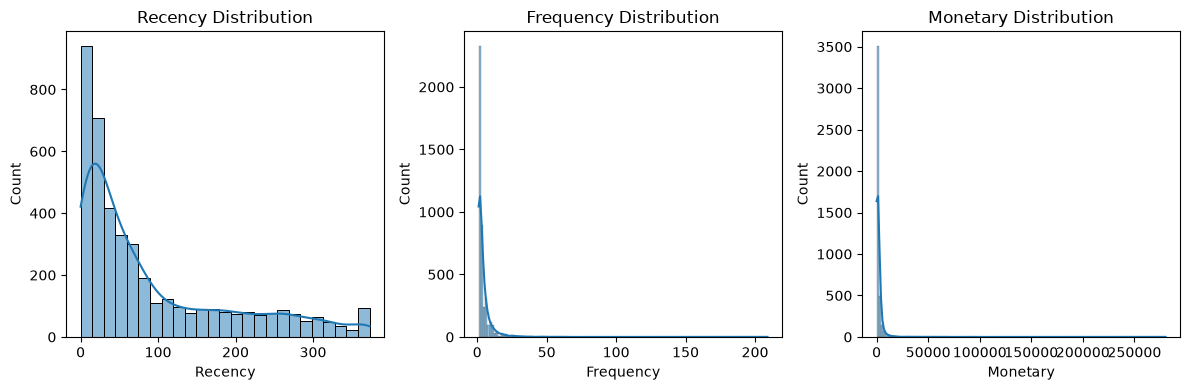

In [184]:
# Plot the distribution of RFM features
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(rfm["Recency"], kde=True)
plt.title("Recency Distribution")

plt.subplot(1, 3, 2)
sns.histplot(rfm["Frequency"], kde=True)
plt.title("Frequency Distribution")

plt.subplot(1, 3, 3)
sns.histplot(rfm["Monetary"], kde=True)
plt.title("Monetary Distribution")

plt.tight_layout()
plt.show()

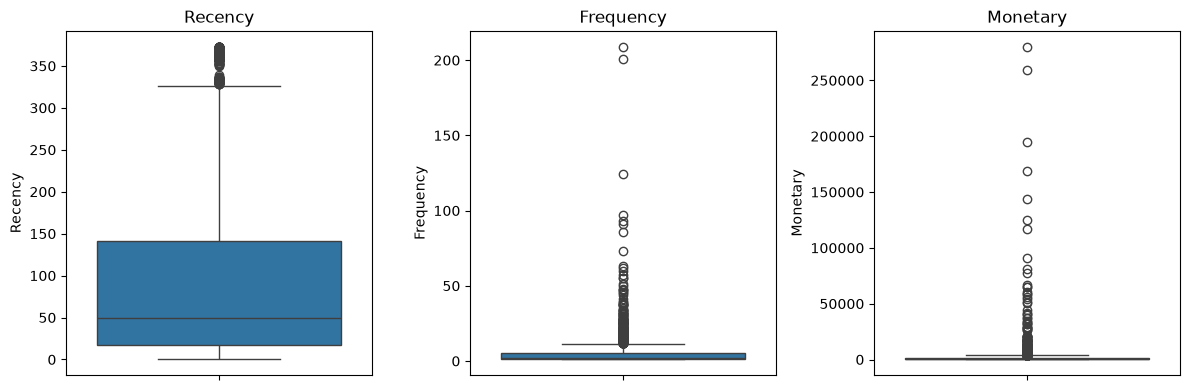

In [187]:
# Plot boxplots to identify extreme values
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=rfm["Recency"])
plt.title("Recency")

plt.subplot(1, 3, 2)
sns.boxplot(y=rfm["Frequency"])
plt.title("Frequency")

plt.subplot(1, 3, 3)
sns.boxplot(y=rfm["Monetary"])
plt.title("Monetary")

plt.tight_layout()
plt.show()


<h3 style="color:green; font-weight:bold">7.1 — Observation</h3>

### Observation

- Teeno RFM features highly right-skewed hain.
- Recency mein comparatively moderate spread hai aur kuch high-value outliers present hain.
- Frequency mein majority customers ki purchase frequency low hai, jabke kuch customers ne bohat zyada transactions ki hain.
- Monetary mein strong right-skewness hai aur kuch customers ka spending amount bohat high hai.
- Frequency aur Monetary ke extreme values genuine high-activity/high-value customers ko represent kar sakti hain, isliye unhein blindly remove nahi karna chahiye.
- K-Means distance-based algorithm hai, isliye extreme skewness ko handle karna zaroori hai.
- Is project mein RFM features par **log transformation** apply karke distributions ko less skewed banayenge, phir scaling karenge.

<h1 style="color:orange; font-weight:bold">Step 8 — Data Transformation & Scaling</h1>

<h3 style="color:green; font-weight:bold">8.1 — Log Transformation</h3>

In [192]:
# Apply log transformation to reduce the effect of extreme values
rfm_log = np.log1p(rfm)

# Display the transformed RFM data
rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,5.786897,0.693147,11.253955
12347,0.693147,2.079442,8.368925
12348,4.317488,1.609438,7.494564
12349,2.944439,0.693147,7.472245
12350,5.736572,0.693147,5.815324


<h3 style="color:blue; font-weight:bold">8.1 — Observation</h3>

- Log transformation ne highly skewed RFM features ki extreme values ka effect reduce kiya hai. Ab data K-Means clustering ke liye zyada suitable hai.

<h3 style="color:green; font-weight:bold">8.2 — Feature Scaling</h3>

In [201]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Scale the transformed RFM features
rfm_scaled = scaler.fit_transform(rfm_log)

# Convert the scaled data back into a DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_log.columns,
    index=rfm_log.index
)

# Display the scaled RFM data
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,1.409894,-0.955214,3.707716
12347,-2.146498,1.074425,1.414903
12348,0.383971,0.386304,0.720024
12349,-0.574674,-0.955214,0.702287
12350,1.374758,-0.955214,-0.614514


<h3 style="color:blue; font-weight:bold">8.2 — Observation</h3>

RFM features ko StandardScaler se scale kiya gaya hai taake Recency, Frequency aur Monetary comparable scale par aa jayen.

Ab data **K-Means clustering ke liye ready** hai.

<h1 style="color:orange; font-weight:bold">Step 9 — K-Means Clustering</h1>

<h3 style="color:green; font-weight:bold">9.1 — Find Optimal Number of Clusters</h3>

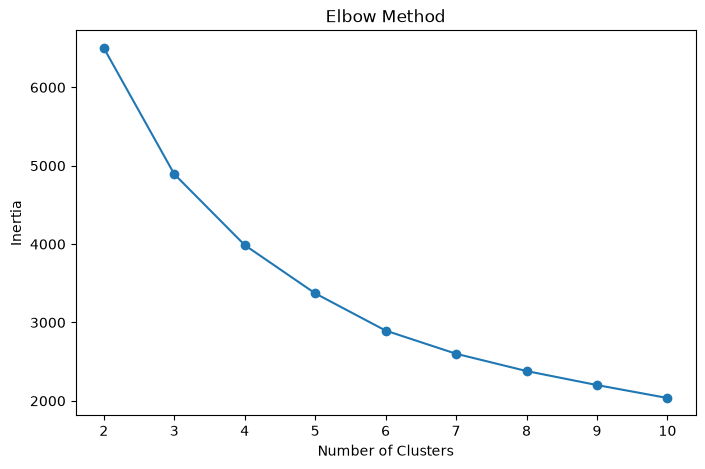

In [204]:
from sklearn.cluster import KMeans

# Calculate inertia for different numbers of clusters
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

<h3 style="color:green; font-weight:bold">9.2 — Silhouette Score</h3>

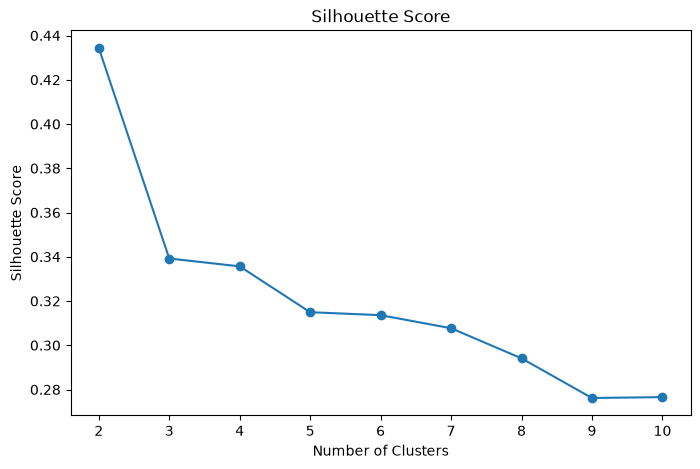

In [205]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score for different numbers of clusters
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

<h3 style="color:blue; font-weight:bold">9.2 — Observation</h3>

### Observation

- Silhouette Score **K = 2** par highest hai, approximately **0.435**.
- K = 3 par score approximately **0.339** aur K = 4 par approximately **0.336** hai.
- Isliye clustering quality ke perspective se **K = 2 strongest candidate** hai.
- Elbow Method mein K = 4 ke around noticeable bend tha, isliye dono methods ko compare karna important tha.
- Ab hum K = 2, 3 aur 4 ke clusters ko actual customer profiles ke saath compare karenge before finalizing the cluster count.

<h1 style="color:orange; font-weight:bold">Step 10 — Final K-Means Model</h1>

<h3 style="color:green; font-weight:bold">10.1 — Compare Candidate Clusters</h3>

In [206]:
# Compare the number of customers in different cluster solutions
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)

    print(f"\nK = {k}")
    print(pd.Series(labels).value_counts().sort_index())


K = 2
0    2683
1    1655
Name: count, dtype: int64

K = 3
0    1688
1     729
2    1921
Name: count, dtype: int64

K = 4
0     808
1    1642
2     685
3    1203
Name: count, dtype: int64


<h3 style="color:blue; font-weight:bold">10.1 — Observation</h3>

Is comparison se hum dekhenge ke K = 2, K = 3 aur K = 4 par customers kis tarah distribute ho rahe hain.

Silhouette Score K = 2 ko support karta hai, lekin final clustering solution ko customer distribution aur business interpretation ke saath validate karna zaroori hai.

<h1 style="color:orange; font-weight:bold">Step 10 — Final K-Means Model</h1>

<h3 style="color:green; font-weight:bold">10.1 — Train Final K-Means Model</h3>

In [207]:
# Create the final K-Means model with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Train the model and assign each customer to a cluster
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Display the first 5 customers with their cluster labels
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,325,1,77183.60,1
12347,1,7,4310.00,1
12348,74,4,1797.24,1
12349,18,1,1757.55,0
12350,309,1,334.40,0


<h3 style="color:green; font-weight:bold">10.2 — Cluster Size</h3>

In [208]:
# Count the number of customers in each cluster
print(rfm["Cluster"].value_counts().sort_index())

Cluster
0    2683
1    1655
Name: count, dtype: int64


<h1 style="color:orange; font-weight:bold">Step 11 — Cluster Profiling & Business Interpretation</h1>

<h3 style="color:green; font-weight:bold">11.1 — RFM Profile of Each Cluster</h3>

In [209]:
# Calculate the average RFM values for each cluster
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

# Display the cluster profiles
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,132.702572,1.676854,498.221954
1,24.800000,8.479154,4562.223197


<h3 style="color:green; font-weight:bold">11.2 — Visualize Cluster Profiles</h3>

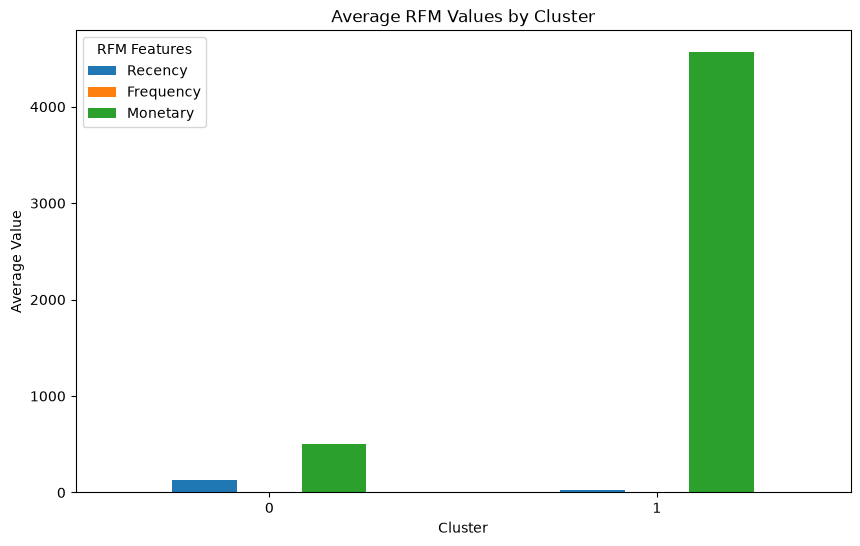

In [210]:
# Plot the average RFM values for each cluster
cluster_profile.plot(kind="bar", figsize=(10, 6))

# Add chart labels and title
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.title("Average RFM Values by Cluster")
plt.xticks(rotation=0)
plt.legend(title="RFM Features")
plt.show()

<h3 style="color:green; font-weight:bold">11.3 — Cluster Comparison</h3>

In [211]:
# Calculate average RFM values for each cluster
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

# Calculate the number of customers in each cluster
cluster_profile["Customers"] = rfm["Cluster"].value_counts()

# Display the complete cluster profile
cluster_profile

,Recency,Frequency,Monetary,Customers
Cluster,,,,
0,132.702572,1.676854,498.221954,2683
1,24.800000,8.479154,4562.223197,1655


<h3 style="color:green; font-weight:bold">11.4 — Customer Segment Naming & Business Insights</h3>

### Cluster 0 — Low-Activity Customers
- 2,683 customers
- Average Recency: ~133 days
- Average Frequency: ~1.68 purchases
- Average Monetary: ~498

Ye customers relatively less recent aur less frequent purchases karte hain, aur unki spending bhi comparatively low hai.

### Cluster 1 — High-Value Customers
- 1,655 customers
- Average Recency: ~25 days
- Average Frequency: ~8.48 purchases
- Average Monetary: ~4,562

Ye customers relatively recent, frequent aur high-spending customers hain.

### Overall Insight
RFM-based K-Means ne customers ko do clearly different purchasing-behavior groups mein divide kiya:
- Low-activity customers
- High-value customers

<h1 style="color:orange; font-weight:bold">Step 12 — Final Visualization</h1>

<h3 style="color:green; font-weight:bold">12.1 — Visualize Customer Clusters</h3>

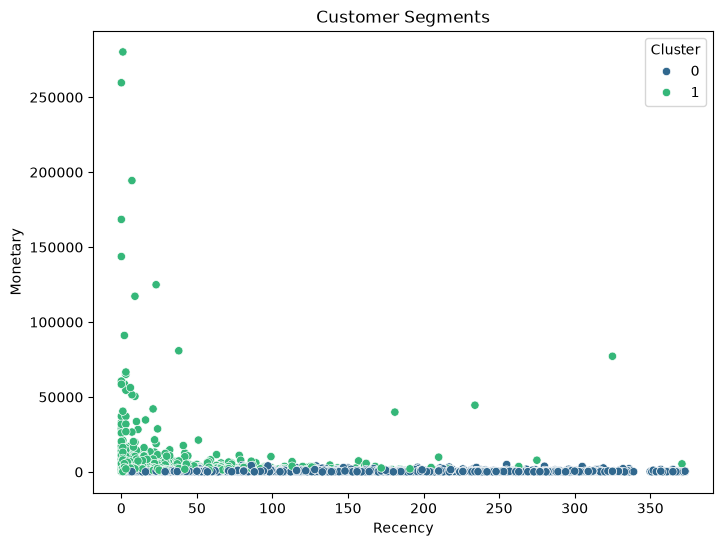

In [212]:
# Plot customers based on Recency and Monetary value
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=rfm["Recency"],
    y=rfm["Monetary"],
    hue=rfm["Cluster"],
    palette="viridis"
)

# Add chart title and labels
plt.title("Customer Segments")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

<h1 style="color:orange; font-weight:bold">Step 13 — Final Project Summary & Conclusion</h1>

<h3 style="color:green; font-weight:bold">13.1 — Project Summary</h3>

### Project Summary

In this project, customer segmentation was performed using RFM analysis and K-Means clustering.

The complete workflow included:

- Data loading and initial inspection
- Data quality checking
- Data cleaning
- TotalAmount feature creation
- RFM feature engineering
- Outlier analysis
- Log transformation
- Feature scaling
- Elbow Method
- Silhouette Score
- K-Means clustering
- Cluster profiling
- Customer segment interpretation
- Final cluster visualization

<h3 style="color:green; font-weight:bold">13.2 — Final Findings</h3>

### Final Findings

The K-Means model divided customers into two distinct groups based on their purchasing behavior.

**Cluster 0 — Low-Activity Customers**
- 2,683 customers
- Lower purchase frequency
- Lower monetary value
- Higher recency

**Cluster 1 — High-Value Customers**
- 1,655 customers
- Higher purchase frequency
- Higher monetary value
- Lower recency

The clustering results demonstrate that RFM features can be used to identify meaningful differences in customer purchasing behavior.

<h3 style="color:green; font-weight:bold">13.3 — Conclusion</h3>

### Conclusion

This project demonstrates the complete application of unsupervised learning for customer segmentation.

RFM features were created from transactional data and used with K-Means clustering to identify groups of customers with different purchasing behaviors.

The resulting customer segments can help businesses understand customer behavior and design more targeted marketing strategies.

<h1 style="color:orange; font-weight:bold">Step 14 — Final Notebook Cleanup</h1>

<h3 style="color:green; font-weight:bold">14.1 — Final Notebook Structure</h3>

1. Dataset
2. Data Understanding + Initial Inspection
3. Data Quality Audit
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. RFM Analysis & Outlier Handling
8. Data Transformation & Scaling
9. K-Means Clustering
10. Final K-Means Model
11. Cluster Profiling & Business Interpretation
12. Final Visualization
13. Final Project Summary & Conclusion

<h3 style="color:green; font-weight:bold">14.2 — Notebook Final Check</h3>

✓ All cells run without errors
✓ Unnecessary cells removed
✓ Code comments present
✓ Section headings properly formatted
✓ Observations added after each major section
✓ Outputs visible
✓ No unnecessary theory
✓ No unused imports/code
✓ Dataset path is documented
✓ Final conclusion included